### Generate Synthetic Data

In [1]:
import numpy as np
import random

def get_data_synthetic(num_samples=1000):
    """
    Generates a synthetic dataset with 1K samples and two dimensions.

    Process:
    - Randomly sample class label y from {0, 1}.
    - Sample x ~ N(mu_y, Sigma_y).
    - mu0 = [-2, -2], mu1 = [2, 2]
    - Sigma0 = Sigma1 = 1 * I
    """
    random.seed(0)
    # Parameters
    mu0 = np.array([-3, -3])
    mu1 = np.array([3, 3])
    cov = 5 * np.eye(2)

    # Generate labels (assuming balanced classes for 1K samples)
    n0 = num_samples // 2
    n1 = num_samples - n0

    # Generate X conditioned on y
    X0 = np.random.multivariate_normal(mu0, cov, n0)
    X1 = np.random.multivariate_normal(mu1, cov, n1)

    # Concatenate
    X = np.vstack((X0, X1))
    y = np.array([0] * n0 + [1] * n1)

    # Shuffle the dataset
    indices = np.random.permutation(num_samples)
    X = X[indices]
    y = y[indices]

    return X, y

def load_data(dataset):
    if(dataset=='synthetic'):
      return get_data_synthetic()
    elif(dataset=='polish'):
      return dl.load_polish()
    elif(dataset == 'compas'):
      return dl.load_compas()

### Different Model Classes Learnt from Data

In [2]:
from sklearn.model_selection import StratifiedKFold
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

# Define Logistic Regression Model
class LogisticRegressionModel(nn.Module):
    def __init__(self, input_dim, seed=None):
        super(LogisticRegressionModel, self).__init__()
        if seed is not None:
            torch.manual_seed(seed)
        self.linear = nn.Linear(input_dim, 1)

    def forward(self, x):
        return torch.sigmoid(self.linear(x))

# Define Neural Network Models
class NeuralNetworkModelSingleLayer(nn.Module):
    def __init__(self, input_dim, hidden_nodes=20, seed=None):
        super(NeuralNetworkModelSingleLayer, self).__init__()
        if seed is not None:
            torch.manual_seed(seed)
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_nodes),
            nn.ReLU(),
            nn.Linear(hidden_nodes, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

class NeuralNetworkModelDoubleLayers(nn.Module):
    def __init__(self, input_dim, hidden_nodes1=50, hidden_nodes2=100, seed=None):
        super(NeuralNetworkModelDoubleLayers, self).__init__()
        if seed is not None:
            torch.manual_seed(seed)
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_nodes1),
            nn.ReLU(),
            nn.Linear(hidden_nodes1, hidden_nodes2),
            nn.ReLU(),
            nn.Linear(hidden_nodes2, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

def train_model(model, X, y, epochs=100, lr=0.01, seed=None):
    """Helper function to train a PyTorch model."""
    if seed is not None:
        torch.manual_seed(seed)

    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # Convert to tensors
    X_tensor = torch.tensor(X, dtype=torch.float32)
    y_tensor = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

    model.train()
    for _ in range(epochs):
        optimizer.zero_grad()
        output = model(X_tensor)
        loss = criterion(output, y_tensor)
        loss.backward()
        optimizer.step()
    return model

def recourse_loss(model, x):
    prob = model(x)
    prob = prob.view(-1)
    target = torch.ones_like(prob)
    return nn.MSELoss()(prob, target)

### Train Multiple Model with the Same Performance

In [3]:
import numpy as np
from sklearn.model_selection import train_test_split
import torch

def compare_and_return_models(d1, d2, f1_type, f2_type, alpha):
    """
    Trains two models on two datasets and returns them if their test accuracies are within alpha.
    """
    X1, y1 = d1
    X2, y2 = d2

    # 80/20 split (fixing seed via random_state)
    X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=42)
    X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

    def train_and_eval(X_train, y_train, X_test, y_test, model_type):
        input_dim = X_train.shape[1]
        model = model_type(input_dim)
        # Using the globally available train_model function
        train_model(model, X_train, y_train)

        model.eval()
        with torch.no_grad():
            X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
            y_test_tensor = torch.tensor(y_test, dtype=torch.float32)
            probs = model(X_test_tensor).squeeze()
            preds = (probs >= 0.5).float()
            acc = (preds == y_test_tensor).float().mean().item()
        return model, acc

    print("Training Model 1...")
    model1, acc1 = train_and_eval(X1_train, y1_train, X1_test, y1_test, f1_type)
    print(f"Model 1 Test Accuracy: {acc1:.4f}")

    print("Training Model 2...")
    model2, acc2 = train_and_eval(X2_train, y2_train, X2_test, y2_test, f2_type)
    print(f"Model 2 Test Accuracy: {acc2:.4f}")

    diff = abs(acc1 - acc2)
    if diff <= alpha:
        print(f"Success: Accuracy difference {diff:.4f} is within alpha {alpha}.")
        return model1, model2
    else:
        print(f"Error: Test accuracies differ by {diff:.4f}, which exceeds alpha {alpha}.")
        return None, None

def test_compare_and_return_half_datasets_same_models(d, f1_type, f2_type, alpha):
    # read the data
    X, y = d
    num_data = X.shape[0]
    half_data = int(num_data/2)

    # Split into two datasets
    X1, y1 = X[:half_data], y[:half_data]
    X2, y2 = X[half_data:], y[half_data:]
    d1 = (X1, y1)
    d2 = (X2, y2)

    m1, m2 = compare_and_return_models(d1, d2, f1_type, f2_type, alpha)

    if m1 is not None and m2 is not None:
        print("Test passed: Models returned successfully.")
    else:
        print("Test failed: Models were not returned.")

In [4]:
import numpy as np
from sklearn.model_selection import train_test_split
import torch

def create_multiplicity_same_model_type(dataset, k, model_class, alpha):
    """
    Divides the dataset into k parts. Trains a model on each part (80% train, 20% test).
    Returns the largest subset of k models whose test accuracies are within alpha of each other.
    Returns None if no subset of size >= 2 is found.
    """
    X, y = dataset
    n_samples = X.shape[0]
    part_size = n_samples // k

    models_stats = []
    print(f"Partitioning dataset ({n_samples} samples) into {k} parts and training models...")

    for i in range(k):
        # 1. Partition the dataset
        start = i * part_size
        # Ensure the last part gets any remainder
        end = (i + 1) * part_size if i < k - 1 else n_samples

        X_part = X[start:end]
        y_part = y[start:end]

        # 2. Split 80/20 for Train/Test
        X_train, X_test, y_train, y_test = train_test_split(
            X_part, y_part, test_size=0.2, random_state=42
        )

        # 3. Train Model
        input_dim = X_train.shape[1]
        model = model_class(input_dim)
        # Assuming train_model is defined in the notebook context
        train_model(model, X_train, y_train, epochs=100, lr=0.01)

        # 4. Compute Accuracy
        model.eval()
        with torch.no_grad():
            X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
            y_test_tensor = torch.tensor(y_test, dtype=torch.float32)
            probs = model(X_test_tensor).squeeze()
            preds = (probs >= 0.5).float()
            acc = (preds == y_test_tensor).float().mean().item()

        models_stats.append({'model': model, 'acc': acc, 'id': i})
        print(f"  Model {i+1}/{k}: Test Accuracy = {acc:.4f}")

    # 5. Find subset within alpha
    # Sort models by accuracy
    models_stats.sort(key=lambda x: x['acc'])

    best_subset = []

    # Sliding window to find the largest subset where (max_acc - min_acc) <= alpha
    left = 0
    for right in range(len(models_stats)):
        # Check if current window [left, right] is valid
        while models_stats[right]['acc'] - models_stats[left]['acc'] > alpha:
            left += 1

        current_window = models_stats[left : right+1]

        # Update best_subset if current is larger
        # Using >= to prefer subsets with higher accuracy if sizes are equal (since list is sorted asc)
        if len(current_window) >= len(best_subset):
            best_subset = current_window

    if len(best_subset) < 2:
        print(f"No subset of models found where accuracies are within alpha {alpha}.")
        return None

    min_acc = best_subset[0]['acc']
    max_acc = best_subset[-1]['acc']
    print(f"Success: Found {len(best_subset)} models with accuracies in [{min_acc:.4f}, {max_acc:.4f}] (Diff: {max_acc-min_acc:.4f} <= {alpha})")

    return [m['model'] for m in best_subset]

# Example Test
# Generate slightly more data for k splits
d_large = get_data_synthetic(2000)
# k=5, so each model gets 400 samples (320 train, 80 test)
subset_models = create_multiplicity_same_model_type(d_large, 5, LogisticRegressionModel, alpha=0.05)

Partitioning dataset (2000 samples) into 5 parts and training models...
  Model 1/5: Test Accuracy = 0.9875
  Model 2/5: Test Accuracy = 0.9750
  Model 3/5: Test Accuracy = 0.9500
  Model 4/5: Test Accuracy = 0.9375
  Model 5/5: Test Accuracy = 0.9500
Success: Found 4 models with accuracies in [0.9500, 0.9875] (Diff: 0.0375 <= 0.05)


### Our Algorithm: Projection, Oracle and the Dynamics

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
# Removed unused import: data_processing.data_loading as dl

def project_l2_ball(x, x0, delta):
    """
    Projects x onto the L2-ball centered at x0 with radius delta.
    Constraint: ||x - x0||_2 <= delta
    """
    diff = x - x0
    norm = torch.norm(diff, p=2)

    # If strictly outside the ball, scale it back to the boundary
    if norm > delta:
        diff = diff * (delta / norm)
        x = x0 + diff
    return x

def oracle_gradient_descent(weights, models, x0, delta, loss_func, lr=0.01, tol=1e-4, num_steps=500, cost_func=None):
    """
    Solves the Oracle problem using Projected Gradient Descent.

    Args:
        weights: Numpy array or Tensor of shape (n,) summing to 1.
        models: List of differentiable PyTorch models.
        x0: Original input (PyTorch Tensor).
        delta: Constraint radius (float).
        loss_func: Function l(model, x) -> differentiable scalar Tensor.
        cost_func: (Optional) Used for verification, but projection handles the constraint.
        lr: Learning rate for the internal optimization.
        num_steps: Maximum number of gradient steps to take.
        tol: Convergence tolerance for the change in x (L2 norm).

    Returns:
        x_opt: The optimized recourse input (PyTorch Tensor).
    """
    # 1. Initialize optimization variable x
    # Start at x0 (or slightly perturbed if needed to break symmetry)
    x = x0.clone().detach().requires_grad_(True)

    # Convert weights to tensor if they aren't already
    if not torch.is_tensor(weights):
        w_tensor = torch.tensor(weights, dtype=torch.float32, device=x0.device)
    else:
        w_tensor = weights.to(x0.device)

    # 2. Define Optimizer (SGD or Adam)
    optimizer = optim.Adam([x], lr=lr)

    # Track previous x for convergence check
    prev_x = x.clone().detach()

    for step in range(num_steps):
        optimizer.zero_grad()

        # 3. Compute Weighted Loss
        # L(x) = sum( w_i * loss(h_i, x) )
        # Initialize total_loss as 0.0 to avoid in-place operations on leaf variables
        total_loss = 0.0
        for i, model in enumerate(models):
            loss_i = loss_func(model, x)
            # Use standard addition, not in-place (+=)
            total_loss = total_loss + w_tensor[i] * loss_i

        # 4. Backpropagation
        total_loss.backward()

        # 5. Gradient Step
        optimizer.step()

        # 6. Projection Step (Enforce Constraint)
        # We manually project the data of x back into the feasible set
        with torch.no_grad():
            x.data = project_l2_ball(x.data, x0, delta)

            # Convergence Check
            if tol is not None:
                dist = torch.norm(x.data - prev_x, p=2).item()
                if dist < tol:
                    # Converged
                    break
                prev_x = x.clone().detach()

    return x.detach()

def solve_robust_recourse_with_oracle(x0, models, delta, loss_func, oracle_func, T=100, eta=None, cost_func=None, B=1):
    """
    Solves the Robust Recourse problem using an Oracle-Efficient Minimax approach.

    Args:
        x0: The original input instance (e.g., numpy array or tensor).
        models: A list of n classifiers [h_1, ..., h_n].
        delta: The float constraint budget for the cost function.
        loss_func: A function l(model, x) -> float returning the loss.
        cost_func: A function c(x_original, x_new) -> float (used by the Oracle).
        oracle_func: A function Oracle(weights, models, x0, delta, loss, cost) -> x_best.
                     It solves min_x sum(w_i * loss_i(x)) s.t. cost <= delta.
        T: Integer number of iterations.
        eta: Float learning rate for the adversary. If None, set theoretically.
        B: Upper bound on the loss function value, used for theoretical learning rate.

    Returns:
        x_bar: The average robust recourse found over T rounds.
        final_weights: The final probability distribution over models.
        x_bar_history: List of average robust recourse vectors at each step t=1...T.
        weight_history: List of weight vectors at each step t=1...T.
        eta_losses_history: List of (eta * losses) vectors at each step t=1...T.
    """
    n = len(models)

    # 1. Initialize Adversary Weights (Uniform Distribution)
    w = np.ones(n) / n

    # Set theoretical learning rate if not provided
    # eta = (1/B) * sqrt(ln(n) / T)
    if eta is None:
        eta = (1.0 / B) * np.sqrt(np.log(n) / T)

    # Storage for the cumulative sum of x (for averaging)
    x_sum = None
    x_bar_history = []
    weight_history = []
    eta_losses_history = []

    for t in range(T):
        # Record weights at the start of the round
        weight_history.append(w.copy())

        # --- Step 1: Agent Best Response (Oracle Call) ---
        # The Agent finds the optimal x_t against the current weighted mixture w_t
        x_t = oracle_func(w, models, x0, delta, loss_func)

        # Initialize accumulator on first iteration
        if x_sum is None:
            x_sum = torch.zeros_like(x_t)
        x_sum += x_t

        # Store average so far
        # We need to detach/clone to avoid storing the graph or reference to changing variable
        current_x_bar = (x_sum / (t + 1)).clone().detach()
        x_bar_history.append(current_x_bar)

        # --- Step 2: Adversary Update (Multiplicative Weights) ---
        # Calculate the loss vector for the chosen x_t against all models
        # Use .item() to detach and get scalar
        losses = np.array([loss_func(h, x_t).item() for h in models])

        # Calculate the update term
        # In the maximization game, w_{t+1} = w_t * exp(eta * losses)
        update_term = eta * losses
        eta_losses_history.append(update_term)

        # Update weights
        w = w * np.exp(update_term)

        # Normalize weights to stay on the simplex
        w = w / np.sum(w)

    # --- Return Time-Averaged Solution ---
    x_bar = x_sum / T

    return x_bar, w, x_bar_history, weight_history, eta_losses_history

## Experiment 1: Convergence


In [6]:
import numpy as np
import torch
from sklearn.model_selection import train_test_split
import random

def train_and_select_candidates(X, y, max_instances = 10, seed=42):
    """
    Trains models on the provided dataset and selects candidate instances
    (predicted negative by ALL models) for recourse.

    Args:
        X: Features (numpy array)
        y: Labels (numpy array)
        max_instances: Number of instances to select
        seed: Random seed for reproducibility

    Returns:
        models: List of trained PyTorch models (1 LR, 3 NNs)
        selected_instances: List of candidate instances (tensors)
    """
    # 0. Set global seeds
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    # 1. 80/20 Train/Test Split
    print(f"Splitting data 80/20 with seed {seed}...")
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)

    input_dim = X.shape[1]

    # Prepare test tensors for evaluation
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
    y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

    # 2. Train Models
    models = []

    # 2a: Logistic Regression
    print("Training Logistic Regression Model...")
    lr_model = LogisticRegressionModel(input_dim, seed=seed)
    train_model(lr_model, X_train, y_train, epochs=50, lr=0.001, seed=seed)

    # Evaluate LR
    lr_model.eval()
    with torch.no_grad():
        preds = (lr_model(X_test_tensor) >= 0.5).float()
        acc = (preds == y_test_tensor).float().mean().item()
    print(f"  Logistic Regression Test Accuracy: {acc:.4f}")

    models.append(lr_model)

    # 2b: 3 Neural Networks
    for i in range(3):
        print(f"Training Neural Network {i+1}...")
        # Use a distinct seed for each NN to ensure diversity in initialization
        current_seed = seed + i + 1
        nn_model = NeuralNetworkModelSingleLayer(input_dim, hidden_nodes=20, seed=current_seed)
        train_model(nn_model, X_train, y_train, epochs=50, lr=0.001, seed=current_seed)

        # Evaluate NN
        nn_model.eval()
        with torch.no_grad():
            preds = (nn_model(X_test_tensor) >= 0.5).float()
            acc = (preds == y_test_tensor).float().mean().item()
        print(f"  Neural Network {i+1} Test Accuracy: {acc:.4f}")

        models.append(nn_model)

    # 3. Find candidates in Test Set (All models prob < 0.5)
    print("Identifying candidates where ALL models predict prob < 0.5...")
    # Set all models to eval mode
    for m in models:
        m.eval()

    candidates = []
    with torch.no_grad():
        # Collect predictions from all models
        all_preds = []
        for model in models:
            preds = model(X_test_tensor).squeeze()
            all_preds.append(preds)

        # Stack to shape [num_models, num_samples]
        all_preds = torch.stack(all_preds)

        # Check if ALL models predict < 0.5
        # (all_preds < 0.5) is a boolean tensor, .all(dim=0) checks across models for each sample
        is_negative = (all_preds < 0.5).all(dim=0)

        # Get indices of samples that satisfy the condition
        indices = is_negative.nonzero(as_tuple=True)[0]

        for idx in indices:
            candidates.append(X_test_tensor[idx])

    print(f"Found {len(candidates)} candidate instances.")

    # 4. Pick max_instances at random
    if len(candidates) > max_instances:
        selected_instances = random.sample(candidates, max_instances)
    else:
        selected_instances = candidates

    return models, selected_instances

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import random
import torch
import os
import glob
import importlib
from sklearn.preprocessing import StandardScaler
import data_processing.data_loading as dl

# --- 2. Define Experiment Function ---
def run_mixed_model_experiment(datasets_dict, max_instances, seed=42, dataset_deltas={}, T=100, B=1, folds=5):
    plot_data = []
    colors = ['blue', 'red', 'green', 'orange', 'purple', 'cyan']

    for i, (name, (X, y)) in enumerate(datasets_dict.items()):
        print(f"\n--- Processing {name} ---")

        # Standardize
        print("  Normalizing data with StandardScaler...")
        scaler = StandardScaler()
        X = scaler.fit_transform(X)

        # Get specific delta for this dataset
        delta = dataset_deltas.get(name, 5.0) # Default to 5.0 if not found
        print(f"  Running for Delta={delta}...")

        # Store trajectories from each fold
        fold_trajectories = []

        for fold in range(folds):
            print(f"    Outer Fold {fold+1}/{folds}...")
            current_seed = seed + fold

            # Train/Select Models & Candidates
            try:
                models, selected_instances = train_and_select_candidates(X, y, max_instances, seed=current_seed)
            except Exception as e:
                print(f"      Error in fold {fold+1}: {e}")
                continue

            if not selected_instances:
                print(f"      No candidates found in Fold {fold+1}. Skipping.")
                continue

            # Collect trajectories for instances in this fold
            instance_trajectories = []

            for idx, x0 in enumerate(selected_instances):
                # Run ORPM (Oracle)
                _, _, x_bar_history, _, _ = solve_robust_recourse_with_oracle(
                    x0, models, delta, recourse_loss, oracle_gradient_descent, T=T, B=B
                )

                # Compute Max Loss curve for this instance
                traj = []
                for x_val in x_bar_history:
                    losses = [recourse_loss(m, x_val).item() for m in models]
                    traj.append(max(losses))
                instance_trajectories.append(traj)

            if instance_trajectories:
                # Average over instances in this fold to get one curve for the fold
                fold_mean = np.mean(instance_trajectories, axis=0)
                fold_trajectories.append(fold_mean)

        if not fold_trajectories:
            print(f"    No successful runs for {name} (Delta={delta}).")
            continue

        # Aggregate across folds
        fold_trajectories = np.array(fold_trajectories)
        mean_curve = np.mean(fold_trajectories, axis=0)
        std_curve = np.std(fold_trajectories, axis=0)

        plot_data.append({ 'name': name, 'Delta': delta, 'mean': mean_curve, 'std': std_curve, 'color': colors[i % len(colors)] })

    # Plotting
    plt.figure(figsize=(12, 8))
    for data in plot_data:
        c = data['color']
        label_str = f"{data['name']} (D={data['Delta']})"

        steps = range(1, T+1)
        # Plot Mean
        plt.plot(steps, data['mean'], color=c, linestyle='-', label=f'{label_str}')
        # Plot Error Bars (Shaded Region)
        plt.fill_between(steps, data['mean'] - data['std'], data['mean'] + data['std'], color=c, alpha=0.2)

    plt.xlabel('Iteration (T)')
    plt.ylabel('Max Recourse Loss (Robustness)')
    plt.title(f'Robust Recourse Convergence (Avg over {folds} Folds)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

Convergence across different datasets


Starting experiment with accuracy tracking...
Error loading Polish dataset: [Errno 2] No such file or directory: '/datasets/polish-companies_clean_uncut.csv'

--- Processing Synthetic ---
  Normalizing data with StandardScaler...
  Running for Delta=10.0...
    Outer Fold 1/2...
Splitting data 80/20 with seed 55...
Training Logistic Regression Model...
  Logistic Regression Test Accuracy: 0.9500
Training Neural Network 1...
  Neural Network 1 Test Accuracy: 0.9500
Training Neural Network 2...
  Neural Network 2 Test Accuracy: 0.8900
Training Neural Network 3...
  Neural Network 3 Test Accuracy: 0.7150
Identifying candidates where ALL models predict prob < 0.5...
Found 75 candidate instances.
    Outer Fold 2/2...
Splitting data 80/20 with seed 56...
Training Logistic Regression Model...
  Logistic Regression Test Accuracy: 0.9250
Training Neural Network 1...
  Neural Network 1 Test Accuracy: 0.8900
Training Neural Network 2...
  Neural Network 2 Test Accuracy: 0.8100
Training Neural Ne

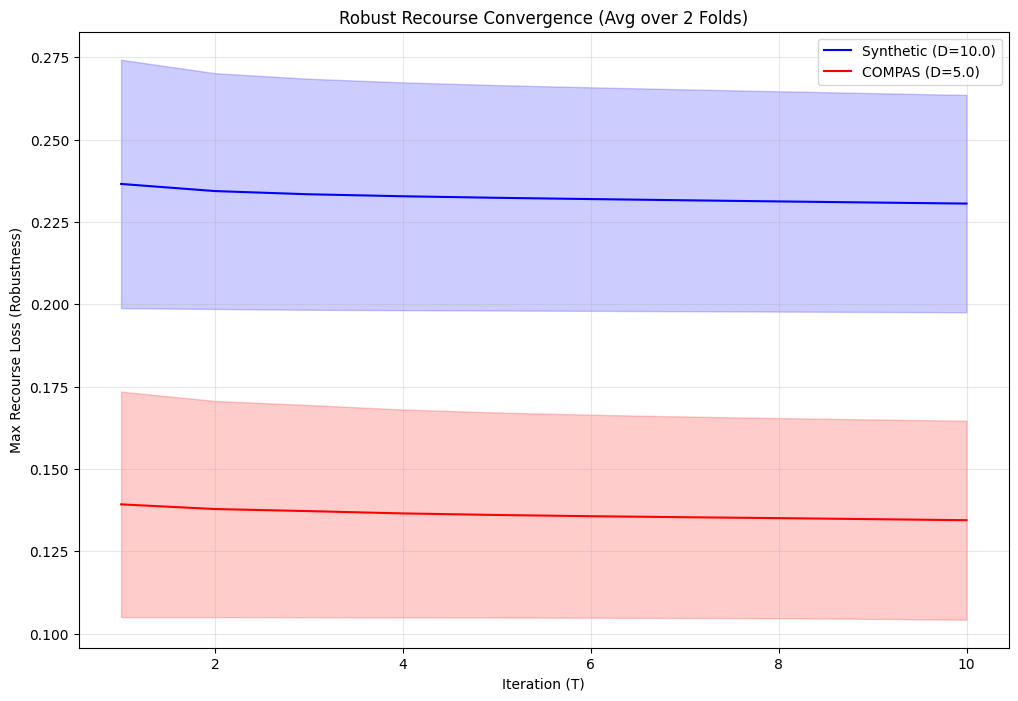

In [9]:
# --- 3. Execution ---
print("Starting experiment with accuracy tracking...")
max_instances = 2
seed = 55 # Initialization seed
T = 10
B = 1
num_folds = 2

# Define Delta per dataset
dataset_deltas = {
    'Synthetic': 10.0,
    'Polish': 5.0,
    'COMPAS': 5.0
}


datasets = {}
# 1. Synthetic Data
X_syn, y_syn = get_data_synthetic(1000)
datasets['Synthetic'] = (X_syn, y_syn)

# 2. Polish Data
try:
    X_pol, y_pol = dl.load_polish()
    datasets['Polish'] = (X_pol, y_pol)
except Exception as e:
    print(f"Error loading Polish dataset: {e}")

# 3. COMPAS Data
try:
    X_compas, y_compas = dl.load_compas()
    datasets['COMPAS'] = (X_compas, y_compas)
except Exception as e:
    print(f"Error loading COMPAS dataset: {e}")

run_mixed_model_experiment(datasets, max_instances, seed=seed, dataset_deltas=dataset_deltas, T=T, B=B, folds=num_folds)

## Experiment 2: Comparison with Baselines


In [10]:
def ADV(x0, models, B, loss_func, T=100, lr=0.01, tol=1e-4):
    """
    ADV (Adversarial Training Baseline for Algorithmic Recourse).
    Optimizes x to minimize the WORST-CASE loss among the FINITE SET of models (Minimax).

    Args:
        x0: Original instance.
        models: List of PyTorch models.
        B: Constraint radius (recourse budget).
        loss_func: Loss function l(model, x).
        T: Maximum number of iterations.
        lr: Learning rate.
        tol: Threshold for change in loss to trigger early stopping.
    """
    # Initialize x at x0
    x = x0.clone().detach().requires_grad_(True)
    history = []

    # Optimizer
    optimizer = torch.optim.Adam([x], lr=lr)

    prev_loss = float('inf')

    for t in range(T):
        optimizer.zero_grad()

        # Compute losses for all models
        losses = []
        for model in models:
            losses.append(loss_func(model, x))

        # Stack losses into a tensor to find the max
        losses_tensor = torch.stack(losses)

        # Identify the worst-case loss (Max)
        max_loss = torch.max(losses_tensor)

        # Early Stopping Check
        current_loss = max_loss.item()
        if abs(prev_loss - current_loss) < tol:
            break
        prev_loss = current_loss

        # Backward pass on the max loss
        max_loss.backward()
        optimizer.step()

        # Projection Step (Constraint: ||x - x0|| <= B)
        with torch.no_grad():
            x.data = project_l2_ball(x.data, x0, B)

        # Store current state
        history.append(x.clone().detach())

    return history

def ROAR(x0, initial_model, delta_model, B, loss_func, T=100, lr=0.01, tol=1e-4):
    x = x0.clone().detach().requires_grad_(True)
    history = []
    optimizer = torch.optim.Adam([x], lr=lr)

    w_init = initial_model.linear.weight.detach().view(-1)
    b_init = initial_model.linear.bias.detach().view(-1)
    device = x.device

    prev_loss = float('inf')

    for t in range(T):
        optimizer.zero_grad()
        x_sign = torch.sign(x.data)
        w_adv = w_init - delta_model * x_sign
        b_adv = b_init - delta_model

        logit = torch.dot(w_adv, x) + b_adv
        prob = torch.sigmoid(logit).view(-1) # Ensure 1D

        # FIX: Make target same shape as prob
        target = torch.ones_like(prob)

        current_loss = nn.MSELoss()(prob, target)

        loss_val = current_loss.item()
        if abs(prev_loss - loss_val) < tol:
            break
        prev_loss = loss_val

        current_loss.backward()
        optimizer.step()

        with torch.no_grad():
            x.data = project_l2_ball(x.data, x0, B)

        history.append(x.clone().detach())

    return history

In [11]:
def ElliCE(x0, models, B, loss_func, T=100, lr=0.01, tol=1e-4):
    # Re-calculate Sigma and omega_c logic as before
    thetas = []
    device = x0.device
    for m in models:
        w = m.linear.weight.detach().view(-1)
        b = m.linear.bias.detach().view(-1)
        theta = torch.cat([w, b])
        thetas.append(theta)
    thetas = torch.stack(thetas).to(device)
    omega_c = torch.mean(thetas, dim=0)
    diff = thetas - omega_c
    N = thetas.shape[0]
    if N > 1:
        Sigma = (diff.T @ diff) / (N - 1)
    else:
        Sigma = torch.eye(len(omega_c)).to(device) * 1e-4
    Sigma = Sigma + torch.eye(len(omega_c)).to(device) * 1e-5

    try:
        Sigma_inv = torch.linalg.inv(Sigma)
    except:
        Sigma_inv = torch.eye(len(omega_c)).to(device)

    dists = []
    for i in range(N):
        d = diff[i]
        dist_sq = (d.T @ Sigma_inv @ d)
        dists.append(dist_sq)

    if N > 1:
        epsilon = max(dists).item() / 2.0
        epsilon *= 1.1
    else:
        epsilon = 0.1

    x = x0.clone().detach().requires_grad_(True)
    history = []
    optimizer = torch.optim.Adam([x], lr=lr)

    prev_loss = float('inf')

    for t in range(T):
        optimizer.zero_grad()
        h_tilde = torch.cat([x, torch.tensor([1.0]).to(device)])
        denom = h_tilde.T @ Sigma @ h_tilde
        if denom < 1e-8: denom = 1e-8
        scale = torch.sqrt(2 * epsilon / denom)
        theta_w = omega_c - scale * (Sigma @ h_tilde)

        logit = torch.dot(theta_w, h_tilde)
        prob = torch.sigmoid(logit).view(-1) # Ensure 1D

        # FIX: Make target same shape as prob
        target = torch.ones_like(prob)

        current_loss = nn.MSELoss()(prob, target)

        loss_val = current_loss.item()
        if abs(prev_loss - loss_val) < tol:
            break
        prev_loss = loss_val

        current_loss.backward()
        optimizer.step()

        with torch.no_grad():
            x.data = project_l2_ball(x.data, x0, B)

        history.append(x.clone().detach())

    return history

In [12]:
import sys
import os

import numpy as np
import torch
import random
from sklearn.model_selection import train_test_split
import torch.nn as nn
import torch.optim as optim

# --- 1. Rashomon Sampling Logic ---
def get_hessian(model, X, y, lambda_reg=1e-5):
    """
    Computes the Hessian of the Binary Cross Entropy loss w.r.t weights.
    H = (1/N) * X^T * S * X + lambda * I
    where S is diagonal with entries p*(1-p)
    """
    model.eval()
    with torch.no_grad():
        # 1. Forward pass to get probabilities
        # X shape: (N, D)
        X_tensor = torch.tensor(X, dtype=torch.float32)
        probs = model(X_tensor).squeeze() # Shape (N,)

        # 2. Compute diagonal S = p * (1-p)
        S = probs * (1 - probs)

        # 3. Compute X^T * S * X
        # We can do (X.T * S) @ X
        # S is a vector, so we broadcast: X.T * S is equivalent to weighting columns of X.T
        X_weighted = X_tensor.T * S
        H = X_weighted @ X_tensor # (D, D)

        # Normalize by N
        H = H / X.shape[0]

        # Add regularization
        H = H + lambda_reg * torch.eye(H.shape[0])

    return H

def sample_from_ellipsoid(central_theta, H, epsilon, num_samples, seed=42):
    """
    Samples weights theta such that (theta - central)^T H (theta - central) <= 2*epsilon
    """
    rng = np.random.default_rng(seed)
    D = central_theta.shape[0]

    # 1. Compute H^{-1/2} (or Cholesky of Inverse)
    # H = L L^T -> H^-1 = L^-T L^-1
    # We want theta = central + delta
    # delta^T H delta <= 2*epsilon
    # Let delta = H^{-1/2} * z, where ||z||^2 <= 2*epsilon

    # Eigendecomposition is stable
    evals, evecs = torch.linalg.eigh(H)
    # H = U * diag(evals) * U^T
    # H^{-1/2} = U * diag(1/sqrt(evals)) * U^T

    inv_sqrt_evals = 1.0 / torch.sqrt(evals)
    H_inv_sqrt = evecs @ torch.diag(inv_sqrt_evals) @ evecs.T

    samples = []
    for i in range(num_samples):
        # Sample z from ball of radius sqrt(2*epsilon)
        # Direction: Uniform on sphere
        u = rng.standard_normal(D)
        u = u / np.linalg.norm(u)

        # Radius: r = R * (random)^(1/D) for uniformity in volume
        R = np.sqrt(2 * epsilon)
        r = R * (rng.random() ** (1.0/D))

        z = torch.tensor(u * r, dtype=torch.float32)

        # Transform
        delta = H_inv_sqrt @ z
        theta = central_theta + delta
        samples.append(theta)

    return samples

def set_model_weights(model, theta):
    """
    Sets the parameters of the LR model from a flat theta vector.
    Assumes theta = [weights, bias]
    """
    input_dim = model.linear.weight.shape[1]
    with torch.no_grad():
        model.linear.weight.copy_(theta[:input_dim].view(1, -1))
        model.linear.bias.copy_(theta[input_dim].view(-1))

# --- 2. Candidate Selection (Using Rashomon Set) ---
def train_and_select_candidates_rashomon(X, y, max_instances=10, seed=42):
    """
    Trains a central Logistic Regression model using 5-Fold CV, generates a Rashomon set,
    and selects candidate instances. Ensures models are Linear for ElliCE compatibility.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

    central_accs = []
    rashomon_avg_accs = []
    final_models = []
    final_candidates = []

    print(f"Starting 5-Fold Cross-Validation (Rashomon Linear) with seed {seed}...")

    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
        # print(f"  CV Fold {fold+1}/5...")
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        input_dim = X.shape[1]
        X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
        y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
        X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
        y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

        # 1. Train Central Model (Linear)
        central_model = LogisticRegressionModel(input_dim, seed=seed)
        train_model(central_model, X_train, y_train, epochs=500, lr=0.01, seed=seed)

        central_model.eval()
        with torch.no_grad():
            preds = (central_model(X_test_tensor) >= 0.5).float()
            acc = (preds == y_test_tensor).float().mean().item()
        central_accs.append(acc)

        # 2. Generate Rashomon Set
        # Augment X for Hessian (w, b)
        X_train_aug = np.hstack([X_train, np.ones((X_train.shape[0], 1))])

        w = central_model.linear.weight.detach().view(-1)
        b = central_model.linear.bias.detach().view(-1)
        central_theta = torch.cat([w, b])

        probs = central_model(X_train_tensor).squeeze().detach()
        S = probs * (1 - probs)
        X_aug_tensor = torch.tensor(X_train_aug, dtype=torch.float32)
        H = (X_aug_tensor.T * S) @ X_aug_tensor / X_train.shape[0]
        H = H + 1e-5 * torch.eye(H.shape[0])

        # Sample Models
        epsilon = 0.05
        num_models = 4
        # Assumes sample_from_ellipsoid is defined in global scope (Cell 18)
        thetas = sample_from_ellipsoid(central_theta, H, epsilon, num_models, seed=seed+fold)

        current_fold_models = []
        fold_rashomon_accs = []

        for i, theta in enumerate(thetas):
            m = LogisticRegressionModel(input_dim, seed=seed+i)
            set_model_weights(m, theta)
            m.eval()
            with torch.no_grad():
                preds = (m(X_test_tensor) >= 0.5).float()
                acc = (preds == y_test_tensor).float().mean().item()
            fold_rashomon_accs.append(acc)
            current_fold_models.append(m)

        rashomon_avg_accs.append(np.mean(fold_rashomon_accs))

        # 3. Last Fold Candidates
        if fold == 4:
            final_models = current_fold_models
            print("    Identifying candidates in Fold 5 where ALL models predict prob < 0.5...")
            with torch.no_grad():
                all_preds = []
                for model in final_models:
                    preds = model(X_test_tensor).squeeze()
                    all_preds.append(preds)
                all_preds = torch.stack(all_preds)
                is_negative = (all_preds < 0.5).all(dim=0)
                indices = is_negative.nonzero(as_tuple=True)[0]
                for idx in indices:
                    final_candidates.append(X_test_tensor[idx])
            print(f"    Found {len(final_candidates)} candidate instances in the last fold.")

    print(f"  CV Results: Central Acc={np.mean(central_accs):.3f}, Ensemble Acc={np.mean(rashomon_avg_accs):.3f}")

    if len(final_candidates) > max_instances:
        selected_instances = random.sample(final_candidates, max_instances)
    else:
        selected_instances = final_candidates

    return final_models, selected_instances

In [13]:
import pandas as pd
import numpy as np
import torch
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
import random
import data_processing.data_loading as dl

def comparison_with_baselines_linear(dataset_name, dataset, recourse_budget=5.0, folds=5, max_instances=5, seed=42, T=200, lr=0.01):
    """
    Compares ORPM, ADV, ElliCE, and ROAR on Robust Validity.
    """
    print(f"\n=== Running Comparison on {dataset_name} (Budget={recourse_budget}) ===")
    X, y = dataset

    # Normalize Data
    scaler = StandardScaler()
    X_norm = scaler.fit_transform(X)

    # Storage for results
    results_validity = {
        'ORPM': [],
        'ADV': [],
        'ElliCE': [],
        'ROAR': []
    }
    results_loss = {
        'ORPM': [],
        'ADV': [],
        'ElliCE': [],
        'ROAR': []
    }

    for fold in range(folds):
        print(f"  Experiment Repetition {fold+1}/{folds}...")
        current_seed = seed + fold

        # 1. Train Models & Select Candidates (Rashomon Set)
        try:
            models, candidates = train_and_select_candidates_rashomon(X_norm, y, max_instances=max_instances, seed=current_seed)
        except Exception as e:
            print(f"    Error in fold {fold+1}: {e}")
            continue

        if not candidates:
            print("    No candidates found.")
            continue

        # --- Prepare ROAR inputs (L-inf Delta) ---
        initial_model = models[0]
        delta_model = 0.0
        with torch.no_grad():
            w_init = initial_model.linear.weight.detach()
            b_init = initial_model.linear.bias.detach()
            for m in models:
                w = m.linear.weight.detach()
                b = m.linear.bias.detach()
                diff_w = torch.abs(w - w_init)
                diff_b = torch.abs(b - b_init)
                max_diff = max(torch.max(diff_w).item(), diff_b.item())
                if max_diff > delta_model:
                    delta_model = max_diff
        print(f"    ROAR Parameters: L-inf Delta = {delta_model:.6f}")

        # Track metrics for this fold
        fold_validity = {'ORPM': 0, 'ADV': 0, 'ElliCE': 0, 'ROAR': 0}
        fold_loss = {'ORPM': 0.0, 'ADV': 0.0, 'ElliCE': 0.0, 'ROAR': 0.0}
        total = len(candidates)

        for x0 in candidates:
            # --- Helper to evaluate result ---
            def evaluate_recourse(x_rec, models, method_name):
                valid = True
                losses = []
                with torch.no_grad():
                    for m in models:
                        prob = m(x_rec).view(-1).item()
                        loss = recourse_loss(m, x_rec).item()
                        losses.append(loss)
                        if prob < 0.5:
                            valid = False
                max_loss = max(losses)
                fold_loss[method_name] += max_loss
                if valid: fold_validity[method_name] += 1

            # --- A. ORPM ---
            x_orpm, _, _, _, _ = solve_robust_recourse_with_oracle(
                x0, models, recourse_budget, recourse_loss, oracle_gradient_descent, T=T, B=1
            )
            evaluate_recourse(x_orpm, models, 'ORPM')

            # --- B. ADV ---
            hist_adv = ADV(x0, models, B=recourse_budget, loss_func=recourse_loss, T=T, lr=lr)
            x_adv = hist_adv[-1]
            evaluate_recourse(x_adv, models, 'ADV')

            # --- C. ElliCE ---
            hist_ellice = ElliCE(x0, models, B=recourse_budget, loss_func=recourse_loss, T=T, lr=lr)
            x_ellice = hist_ellice[-1]
            evaluate_recourse(x_ellice, models, 'ElliCE')

            # --- D. ROAR ---
            hist_roar = ROAR(x0, initial_model, delta_model, B=recourse_budget, loss_func=recourse_loss, T=T, lr=lr)
            x_roar = hist_roar[-1]
            evaluate_recourse(x_roar, models, 'ROAR')

        # Calculate Fold Averages
        if total > 0:
            for method in ['ORPM', 'ADV', 'ElliCE', 'ROAR']:
                results_validity[method].append(fold_validity[method] / total)
                results_loss[method].append(fold_loss[method] / total)

    # Aggregate Results
    summary = {}
    for method in ['ORPM', 'ADV', 'ElliCE', 'ROAR']:
        if results_validity[method]:
            v_mean = np.mean(results_validity[method]) * 100
            v_std = np.std(results_validity[method]) * 100
            l_mean = np.mean(results_loss[method])
            l_std = np.std(results_loss[method])
            summary[f"{method} Validity"] = f"{v_mean:.2f}% (+/- {v_std:.2f})"
            summary[f"{method} Loss"] = f"{l_mean:.4f} (+/- {l_std:.4f})"
        else:
            summary[f"{method} Validity"] = "N/A"
            summary[f"{method} Loss"] = "N/A"

    return pd.DataFrame(summary, index=[dataset_name])

In [14]:
import numpy as np
import random
import pandas as pd
import data_processing.data_loading as dl

# --- Execution of Comparison ---
print("Starting full comparison experiment (Re-run with ADV, ROAR, and ElliCE)...")
all_results = []

# Configuration
SEEDS = 42
FOLDS = 2
INSTANCES = 2
BUDGET = 2.0
T_STEPS = 10

# 1. Synthetic
print("Loading Synthetic...")
X_syn, y_syn = get_data_synthetic(20000)
res_syn = comparison_with_baselines_linear("Synthetic", (X_syn, y_syn), recourse_budget=BUDGET, folds=FOLDS, max_instances=INSTANCES, seed=SEEDS, T=T_STEPS)
all_results.append(res_syn)

# 2. Polish
try:
    print("Loading Polish...")
    X_pol, y_pol = dl.load_polish()
    res_pol = comparison_with_baselines_linear("Polish", (X_pol, y_pol), recourse_budget=BUDGET, folds=FOLDS, max_instances=INSTANCES, seed=SEEDS, T=T_STEPS)
    all_results.append(res_pol)
except Exception as e:
    print(f"Skipping Polish: {e}")

# 3. COMPAS
try:
    print("Loading COMPAS...")
    X_com, y_com = dl.load_compas()
    res_com = comparison_with_baselines_linear("COMPAS", (X_com, y_com), recourse_budget=BUDGET, folds=FOLDS, max_instances=INSTANCES, seed=SEEDS, T=T_STEPS)
    all_results.append(res_com)
except Exception as e:
    print(f"Skipping COMPAS: {e}")

# --- Separate and Display Tables ---
if all_results:
    final_table = pd.concat(all_results)

    # Split columns based on keyword
    validity_cols = [c for c in final_table.columns if "Validity" in c]
    loss_cols = [c for c in final_table.columns if "Loss" in c]

    print("\n=== Robust Validity (% Accepted by All Models) ===")
    display(final_table[validity_cols])

    print("\n=== Average Robust Loss (Minimizing Worst-Case) ===")
    display(final_table[loss_cols])
else:
    print("No results generated.")

Starting full comparison experiment (Re-run with ADV, ROAR, and ElliCE)...
Loading Synthetic...

=== Running Comparison on Synthetic (Budget=2.0) ===
  Experiment Repetition 1/2...
Starting 5-Fold Cross-Validation (Rashomon Linear) with seed 42...
    Identifying candidates in Fold 5 where ALL models predict prob < 0.5...
    Found 1929 candidate instances in the last fold.
  CV Results: Central Acc=0.971, Ensemble Acc=0.957
    ROAR Parameters: L-inf Delta = 3.960706


/var/folders/_j/bm660t5d6c3c93gf29_zqwkn_5fhrr/T/ipykernel_18867/847554180.py:28: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:3618.)
  dist_sq = (d.T @ Sigma_inv @ d)


  Experiment Repetition 2/2...
Starting 5-Fold Cross-Validation (Rashomon Linear) with seed 43...
    Identifying candidates in Fold 5 where ALL models predict prob < 0.5...
    Found 1819 candidate instances in the last fold.
  CV Results: Central Acc=0.971, Ensemble Acc=0.957
    ROAR Parameters: L-inf Delta = 1.624905
Loading Polish...
Skipping Polish: [Errno 2] No such file or directory: '/datasets/polish-companies_clean_uncut.csv'
Loading COMPAS...

=== Running Comparison on COMPAS (Budget=2.0) ===
  Experiment Repetition 1/2...
Starting 5-Fold Cross-Validation (Rashomon Linear) with seed 42...
    Identifying candidates in Fold 5 where ALL models predict prob < 0.5...
    Found 512 candidate instances in the last fold.
  CV Results: Central Acc=0.671, Ensemble Acc=0.623
    ROAR Parameters: L-inf Delta = 1.275829
  Experiment Repetition 2/2...
Starting 5-Fold Cross-Validation (Rashomon Linear) with seed 43...
    Identifying candidates in Fold 5 where ALL models predict prob < 0.

,ORPM Validity,ADV Validity,ElliCE Validity,ROAR Validity
Synthetic,75.00% (+/- 25.00),0.00% (+/- 0.00),0.00% (+/- 0.00),0.00% (+/- 0.00)
COMPAS,25.00% (+/- 25.00),0.00% (+/- 0.00),0.00% (+/- 0.00),0.00% (+/- 0.00)



=== Average Robust Loss (Minimizing Worst-Case) ===


,ORPM Loss,ADV Loss,ElliCE Loss,ROAR Loss
Synthetic,0.1056 (+/- 0.0864),0.9037 (+/- 0.0374),0.9036 (+/- 0.0375),0.9390 (+/- 0.0180)
COMPAS,0.3611 (+/- 0.0363),0.6970 (+/- 0.0644),0.6985 (+/- 0.0634),0.7613 (+/- 0.0582)


In [15]:
import lime
import lime.lime_tabular
import numpy as np
import torch

def linearize_models_lime(models, x0, X_train):
    """
    Generates local linear surrogates for a list of models using LIME centered at x0.

    Args:
        models: List of PyTorch models (classifiers).
        x0: Numpy array representing the instance to explain.
        X_train: Numpy array of training data (used for LIME statistics).

    Returns:
        List of LogisticRegressionModel objects initialized with LIME coefficients.
    """
    input_dim = X_train.shape[1]

    # Initialize LIME explainer
    # discretize_continuous=False ensures we get coefficients for the continuous features directly
    explainer = lime.lime_tabular.LimeTabularExplainer(
        training_data=X_train,
        mode='classification',
        discretize_continuous=False,
        verbose=False
    )

    surrogates = []

    for model in models:
        # LIME expects a function that takes numpy array (n_samples, n_features)
        # and returns (n_samples, n_classes) probabilities.
        def predict_proba_fn(X_numpy):
            # Convert numpy array to PyTorch tensor
            X_tensor = torch.tensor(X_numpy, dtype=torch.float32)

            # Ensure model is in eval mode
            model.eval()
            with torch.no_grad():
                # Model outputs probability of class 1 (sigmoid output)
                prob_1 = model(X_tensor).numpy().flatten()
                # Calculate probability of class 0
                prob_0 = 1 - prob_1
                # Stack to get (N, 2) array as expected by LIME
                return np.vstack((prob_0, prob_1)).T

        # Generate explanation for x0
        # num_features=input_dim ensures we get weights for all features, not just top K
        exp = explainer.explain_instance(
            data_row=x0,
            predict_fn=predict_proba_fn,
            num_features=input_dim
        )

        # Extract weights and intercept for class 1
        # local_exp is a dictionary: {class_label: [(feature_idx, weight), ...]}
        local_exp = exp.local_exp[1]
        intercept = exp.intercept[1]

        # Construct full weight vector
        w = np.zeros(input_dim)
        for feature_idx, weight in local_exp:
            w[feature_idx] = weight

        # Create a new surrogate LogisticRegressionModel
        surrogate = LogisticRegressionModel(input_dim)

        # Manually set the weights and bias of the surrogate
        with torch.no_grad():
            surrogate.linear.weight.copy_(torch.tensor(w, dtype=torch.float32).view(1, -1))
            surrogate.linear.bias.copy_(torch.tensor(intercept, dtype=torch.float32))

        surrogates.append(surrogate)

    return surrogates

print("Function 'linearize_models_lime' defined successfully.")

Function 'linearize_models_lime' defined successfully.


In [16]:
import pandas as pd
import numpy as np
import torch
from sklearn.preprocessing import StandardScaler
import random

def comparison_with_baselines_nonlinear(dataset_name, dataset, recourse_budget=2.0, folds=2, max_instances=5, seed=42, T=100):
    """
    Compares ORPM and ADV (on original models) vs ElliCE and ROAR (on LIME surrogates).
    Evaluates all resulting recourses on the ORIGINAL models.
    """
    print(f"\n=== Running Non-Linear Comparison on {dataset_name} (Budget={recourse_budget}) ===")
    X, y = dataset

    # Normalize Data
    scaler = StandardScaler()
    X_norm = scaler.fit_transform(X)

    # Storage for results
    results_validity = {
        'ORPM': [],
        'ADV': [],
        'ElliCE': [],
        'ROAR': []
    }
    results_loss = {
        'ORPM': [],
        'ADV': [],
        'ElliCE': [],
        'ROAR': []
    }

    for fold in range(folds):
        print(f"  Experiment Repetition {fold+1}/{folds}...")
        current_seed = seed + fold

        # 1. Train Models (Mixed: LR + NNs) & Select Candidates
        # We reuse the function from Experiment 1 which trains 1 LR and 3 NNs
        try:
            models, candidates = train_and_select_candidates(X_norm, y, max_instances=max_instances, seed=current_seed)
        except Exception as e:
            print(f"    Error in fold {fold+1}: {e}")
            continue

        if not candidates:
            print("    No candidates found.")
            continue

        # Track metrics for this fold
        fold_validity = {'ORPM': 0, 'ADV': 0, 'ElliCE': 0, 'ROAR': 0}
        fold_loss = {'ORPM': 0.0, 'ADV': 0.0, 'ElliCE': 0.0, 'ROAR': 0.0}
        total = len(candidates)

        # We need X_train to pass to LIME. In train_and_select_candidates, split is 80/20.
        # Re-create split to get X_train.
        X_train, _, _, _ = train_test_split(X_norm, y, test_size=0.2, random_state=current_seed)

        for x0 in candidates:
            # --- A. Generate Surrogates using LIME ---
            # x0 is a tensor, convert to numpy for LIME
            x0_np = x0.numpy()
            surrogate_models = linearize_models_lime(models, x0_np, X_train)

            # --- B. Calculate ROAR delta_model on Surrogates ---
            initial_surrogate = surrogate_models[0]
            delta_model = 0.0
            with torch.no_grad():
                w_init = initial_surrogate.linear.weight.detach()
                b_init = initial_surrogate.linear.bias.detach()
                for m in surrogate_models:
                    w = m.linear.weight.detach()
                    b = m.linear.bias.detach()
                    diff_w = torch.abs(w - w_init)
                    diff_b = torch.abs(b - b_init)
                    max_diff = max(torch.max(diff_w).item(), diff_b.item())
                    if max_diff > delta_model:
                        delta_model = max_diff
            # print(f"    LIME Surrogates ROAR Delta: {delta_model:.6f}")

            # --- Helper to evaluate result on ORIGINAL models ---
            def evaluate_recourse(x_rec, original_models, method_name):
                valid = True
                losses = []
                with torch.no_grad():
                    for m in original_models:
                        prob = m(x_rec).view(-1).item()
                        loss = recourse_loss(m, x_rec).item()
                        losses.append(loss)
                        if prob < 0.5:
                            valid = False
                max_loss = max(losses)
                fold_loss[method_name] += max_loss
                if valid: fold_validity[method_name] += 1

            # --- C. Run Methods ---

            # 1. ORPM (on ORIGINAL models)
            x_orpm, _, _, _, _ = solve_robust_recourse_with_oracle(
                x0, models, recourse_budget, recourse_loss, oracle_gradient_descent, T=T, B=1
            )
            evaluate_recourse(x_orpm, models, 'ORPM')

            # 2. ADV (on ORIGINAL models)
            # Optimization directly against the non-linear models
            hist_adv = ADV(x0, models, B=recourse_budget, loss_func=recourse_loss, T=T, lr=0.01)
            x_adv = hist_adv[-1]
            evaluate_recourse(x_adv, models, 'ADV')

            # 3. ElliCE (on SURROGATE models)
            # optimize x against surrogates, evaluate on original
            hist_ellice = ElliCE(x0, surrogate_models, B=recourse_budget, loss_func=recourse_loss, T=T, lr=0.01)
            x_ellice = hist_ellice[-1]
            evaluate_recourse(x_ellice, models, 'ElliCE')

            # 4. ROAR (on SURROGATE models)
            # optimize x against surrogates, evaluate on original
            hist_roar = ROAR(x0, initial_surrogate, delta_model, B=recourse_budget, loss_func=recourse_loss, T=T, lr=0.01)
            x_roar = hist_roar[-1]
            evaluate_recourse(x_roar, models, 'ROAR')

        # Calculate Fold Averages
        if total > 0:
            for method in ['ORPM', 'ADV', 'ElliCE', 'ROAR']:
                results_validity[method].append(fold_validity[method] / total)
                results_loss[method].append(fold_loss[method] / total)

    # Aggregate Results
    summary = {}
    for method in ['ORPM', 'ADV', 'ElliCE', 'ROAR']:
        if results_validity[method]:
            v_mean = np.mean(results_validity[method]) * 100
            v_std = np.std(results_validity[method]) * 100
            l_mean = np.mean(results_loss[method])
            l_std = np.std(results_loss[method])
            summary[f"{method} Validity"] = f"{v_mean:.2f}% (+/- {v_std:.2f})"
            summary[f"{method} Loss"] = f"{l_mean:.4f} (+/- {l_std:.4f})"
        else:
            summary[f"{method} Validity"] = "N/A"
            summary[f"{method} Loss"] = "N/A"

    return pd.DataFrame(summary, index=[dataset_name])

print("Function 'comparison_with_baselines_nonlinear' defined successfully.")

Function 'comparison_with_baselines_nonlinear' defined successfully.


In [ ]:
import torch
import torch.nn as nn

all_results_nonlinear = []

# Configuration
SEEDS = 42
FOLDS = 2
INSTANCES = 10
BUDGET = 2.0
T_STEPS = 100

# 1. Synthetic
print("Processing Synthetic...")
res_syn_nl = comparison_with_baselines_nonlinear("Synthetic", (X_syn, y_syn), recourse_budget=BUDGET, folds=FOLDS, max_instances=INSTANCES, seed=SEEDS, T=T_STEPS)
all_results_nonlinear.append(res_syn_nl)

# 2. Polish
try:
    print("Processing Polish...")
    res_pol_nl = comparison_with_baselines_nonlinear("Polish", (X_pol, y_pol), recourse_budget=BUDGET, folds=FOLDS, max_instances=INSTANCES, seed=SEEDS, T=T_STEPS)
    all_results_nonlinear.append(res_pol_nl)
except Exception as e:
    print(f"Skipping Polish: {e}")

# 3. COMPAS
try:
    print("Processing COMPAS...")
    res_com_nl = comparison_with_baselines_nonlinear("COMPAS", (X_com, y_com), recourse_budget=BUDGET, folds=FOLDS, max_instances=INSTANCES, seed=SEEDS, T=T_STEPS)
    all_results_nonlinear.append(res_com_nl)
except Exception as e:
    print(f"Skipping COMPAS: {e}")

# --- Separate and Display Tables ---
if all_results_nonlinear:
    final_table_nl = pd.concat(all_results_nonlinear)

    # Split columns based on keyword
    validity_cols = [c for c in final_table_nl.columns if "Validity" in c]
    loss_cols = [c for c in final_table_nl.columns if "Loss" in c]

    print("\n=== Non-Linear Robust Validity (% Accepted by All Models) ===")
    display(final_table_nl[validity_cols])

    print("\n=== Non-Linear Average Robust Loss (Minimizing Worst-Case) ===")
    display(final_table_nl[loss_cols])
else:
    print("No results generated.")

Processing Synthetic...

=== Running Non-Linear Comparison on Synthetic (Budget=2.0) ===
  Experiment Repetition 1/2...
Splitting data 80/20 with seed 42...
Training Logistic Regression Model...
  Logistic Regression Test Accuracy: 0.9700
Training Neural Network 1...
  Neural Network 1 Test Accuracy: 0.8620
Training Neural Network 2...
  Neural Network 2 Test Accuracy: 0.8965
Training Neural Network 3...
  Neural Network 3 Test Accuracy: 0.9463
Identifying candidates where ALL models predict prob < 0.5...
Found 1465 candidate instances.
